# F1 Corner Clustering

Clusters all detected corners across the 2024 F1 season using k-means on 7 telemetry features, then visualizes the result in an interactive 3D scatter (PCA-compressed).

In [1]:
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import fastf1

from corner_utils import (
    compute_curvature,
    detect_corners,
    extract_features,
    KNOWN_CORNER_COUNTS,
)

# -- Dark theme (matches identification notebook) -------------------------------
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#111111',
    'axes.edgecolor':   '#333',
    'axes.labelcolor':  '#ccc',
    'text.color':       'white',
    'xtick.color':      '#888',
    'ytick.color':      '#888',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.4,
    'axes.grid':        True,
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#444',
    'font.family':      'comic sans ms',
})

In [2]:
YEAR      = 2024
SESSION   = 'Q'
CACHE_DIR = './cashe/f1_casche'

CORNER_COUNT_OVERRIDES = {}

os.makedirs(CACHE_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

schedule = fastf1.get_event_schedule(YEAR, include_testing=False)
TRACKS   = schedule['EventName'].tolist()

print(f'{len(TRACKS)} events -- {YEAR} {SESSION}')

24 events -- 2024 Q


## Section 1 -- Build the Corner Dataset

For each circuit: load fastest qualifying lap -> detect corners -> extract telemetry features -> collect into a flat DataFrame.

**Features used for clustering:**

| Feature | Description |
|---|---|
| `speed_min` | Speed at the apex (typically)|
| `speed_drop` | Entry speed minus apex speed (deceleration magnitude) |
| `kappa_max` | Peak curvature at apex (geometric tightness) |
| `lat_g_max` | Lateral G-force proxy |
| `brake_frac` | Mean brake value through corner window |
| `throttle_mean` | Mean throttle (%) through corner window |
| `gear_apex` | Gear at apex (speed class proxy) |

In [3]:
FEATURE_COLS = [
    'speed_min', 'speed_drop', 'kappa_max',
    'lat_g_max', 'brake_frac', 'throttle_mean', 'gear_apex',
]

rows = []
failed = []

for gp in TRACKS:
    try:
        session = fastf1.get_session(YEAR, gp, SESSION)
        session.load(telemetry=True, laps=True, weather=False, messages=False)

        fastest = session.laps.pick_fastest()
        if fastest is None or (isinstance(fastest, pd.Series) and fastest.empty):
            fastest = session.laps.sort_values('LapTime').iloc[0]

        tel   = fastest.get_telemetry().add_distance()
        x_raw = tel['X'].values.astype(float)
        y_raw = tel['Y'].values.astype(float)
        dist  = tel['Distance'].values.astype(float)
        speed = tel['Speed'].values.astype(float)

        kappa, x_s, y_s = compute_curvature(x_raw, y_raw)
        kappa_smooth     = gaussian_filter1d(kappa, sigma=5)
        abs_kappa        = np.abs(kappa_smooth)

        if 'Steering' in tel.columns:
            steer_arr  = tel['Steering'].values.astype(float)
            steer_dist = dist
        else:
            steer_arr = steer_dist = None

        target  = CORNER_COUNT_OVERRIDES.get(gp) or KNOWN_CORNER_COUNTS.get(gp)
        corners = detect_corners(
            abs_kappa, dist, speed, kappa_smooth,
            target_count=target,
            steering_arr=steer_arr,
            steer_dist=steer_dist,
        )

        n_ok = 0
        for c in corners:
            feats = extract_features(c, tel, abs_kappa)
            if feats is None:
                continue
            row = {
                'circuit':    gp,
                'corner_num': c['corner_num'],
                'direction':  c['direction'],
                **feats,
            }
            rows.append(row)
            n_ok += 1

        print(f'  {gp:32s}  {n_ok:2d} corners extracted  [{fastest["Driver"]}]')

    except Exception as exc:
        warnings.warn(f'SKIP {gp}: {exc}')
        failed.append(gp)

df = pd.DataFrame(rows)
df_clean = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)

print(f'\nTotal corners: {len(df)}  |  After NaN drop: {len(df_clean)}')
if failed:
    print(f'Skipped circuits: {failed}')
df_clean[FEATURE_COLS].describe().round(2)

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']
c:\Users\Harrison\Desktop\Clustering\corner_utils.py:114: UserWarning: Corner calibration: target=15, achieved=13 (closest possible)
  warnings.warn(
core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.

  Bahrain Grand Prix                13 corners extracted  [LEC]


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
c:\Users\Harrison\Desktop\Clustering\corner_utils.py:114: UserWarning: Corner calibration: target=27, achieved=19 (closest possible)
  warnings.warn(
core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  Saudi Arabian Grand Prix          19 corners extracted  [VER]


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 19 drivers: ['1', '55', '11', '4', '16', '81', '63', '22', '18', '14', '44', '23', '77', '20', '31', '27', '10', '3', '24']
c:\Users\Harrison\Desktop\Clustering\corner_utils.py:114: UserWarning: Corner calibration: target=16, achieved=15 (closest possible)
  warnings.warn(
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


...

req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '63', '4', '81', '16', '44', '55', '14', '11', '20', '10', '24', '77', '22', '18', '23', '30', '27', '43', '31']
c:\Users\Harrison\Desktop\Clustering\corner_utils.py:114: UserWarning: Corner calibration: target=16, achieved=13 (closest possible)
  warnings.warn(
core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  Qatar Grand Prix                  13 corners extracted  [VER]


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '55', '27', '1', '10', '63', '14', '77', '11', '22', '30', '18', '16', '20', '23', '24', '44', '43', '61']
c:\Users\Harrison\Desktop\Clustering\corner_utils.py:114: UserWarning: Corner calibration: target=16, achieved=13 (closest possible)
  warnings.warn(


  Abu Dhabi Grand Prix              13 corners extracted  [NOR]

Total corners: 335  |  After NaN drop: 335


,speed_min,speed_drop,kappa_max,lat_g_max,brake_frac,throttle_mean,gear_apex
count,335.00,335.00,335.00,335.00,335.00,335.00,335.00
mean,161.02,70.73,0.00,0.81,0.23,58.58,4.60
std,72.31,69.12,0.00,0.54,0.19,28.34,1.76
min,46.00,0.00,0.00,0.09,0.00,3.65,1.00
25%,98.00,0.31,0.00,0.44,0.00,35.61,3.00
50%,142.00,52.00,0.00,0.65,0.26,50.03,4.00
75%,221.50,126.48,0.00,1.01,0.41,92.10,6.00
max,323.00,246.00,0.01,3.33,0.61,100.00,8.00


## Section 2 -- Preprocessing

StandardScaler normalizes each feature to zero mean and unit variance -- essential for k-means because the algorithm is distance-based and features live on very different scales (km/h vs 1/m).

In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[FEATURE_COLS])

print('Feature matrix shape:', X_scaled.shape)
print('Mean (should be ~0):', X_scaled.mean(axis=0).round(6))
print('Std  (should be ~1):', X_scaled.std(axis=0).round(6))

Feature matrix shape: (335, 7)
Mean (should be ~0): [ 0. -0.  0.  0.  0. -0. -0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1.]


## Section 3 -- Elbow Method (Choose k)

Run k-means for k = 2...10 and plot inertia (WCSS) and silhouette score. Look for the "elbow" in inertia (where adding more clusters yields diminishing returns) and the peak in silhouette score. Then set `K` in Section 4.

c:\Users\Harrison\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Harrison\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Harrison\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Harrison\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

  k=2  inertia=  1006.0  silhouette=0.4774
  k=3  inertia=   679.6  silhouette=0.4045
  k=4  inertia=   555.2  silhouette=0.3656
  k=5  inertia=   467.7  silhouette=0.3775
  k=6  inertia=   398.0  silhouette=0.3829


c:\Users\Harrison\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Harrison\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Harrison\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Harrison\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

  k=7  inertia=   350.3  silhouette=0.3307
  k=8  inertia=   315.8  silhouette=0.3245
  k=9  inertia=   288.8  silhouette=0.3241
  k=10  inertia=   266.2  silhouette=0.3133


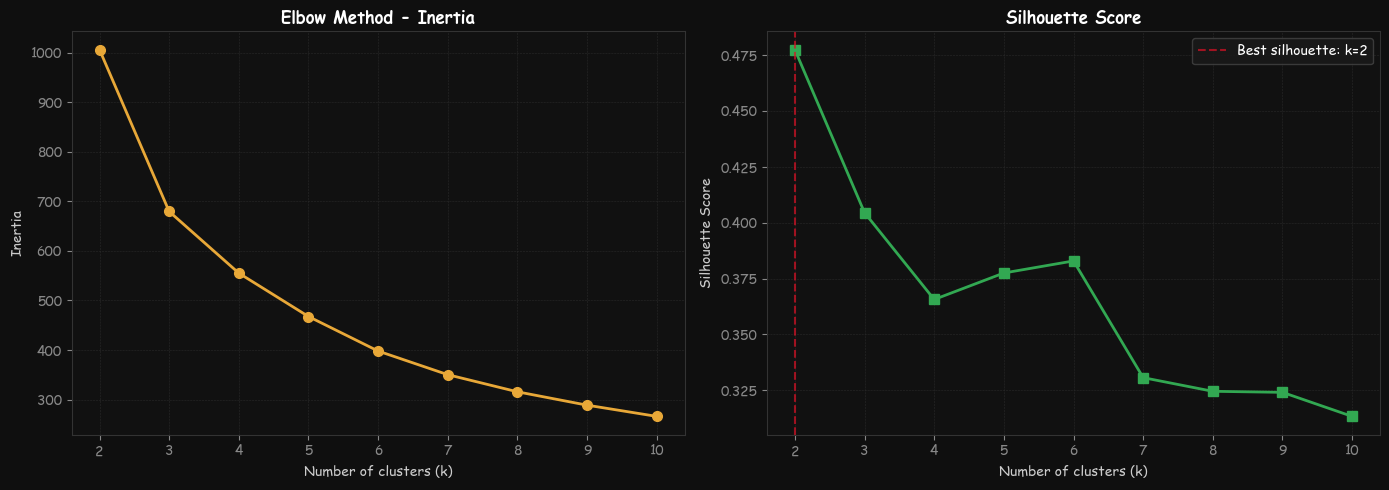

Suggested k by silhouette: 2


In [5]:
K_RANGE    = range(2, 11)
inertias   = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'  k={k}  inertia={km.inertia_:8.1f}  silhouette={silhouettes[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f0f')

ax1 = axes[0]
ax1.plot(list(K_RANGE), inertias, 'o-', color='#e8a838', linewidth=2, markersize=7)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method - Inertia', color='white', fontweight='bold')
ax1.set_xticks(list(K_RANGE))

ax2 = axes[1]
ax2.plot(list(K_RANGE), silhouettes, 's-', color='#32a852', linewidth=2, markersize=7)
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score', color='white', fontweight='bold')
ax2.set_xticks(list(K_RANGE))

best_k_sil = list(K_RANGE)[np.argmax(silhouettes)]
ax2.axvline(best_k_sil, color='#db1226', linestyle='--', alpha=0.7,
            label=f'Best silhouette: k={best_k_sil}')
ax2.legend()

plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'Suggested k by silhouette: {best_k_sil}')

## Section 4 -- K-Means Clustering

**Edit `K` below based on the elbow plot above, then re-run this cell.**

In [6]:
K = 6

km_final = KMeans(n_clusters=K, random_state=42, n_init=20)
df_clean = df_clean.copy()
df_clean['cluster'] = km_final.fit_predict(X_scaled)

# -- Cluster summary ------------------------------------------------------------
summary = (
    df_clean
    .groupby('cluster')[FEATURE_COLS]
    .mean()
    .sort_values('speed_min')
    .round(2)
)

# Auto-label clusters by ascending apex speed
CLUSTER_LABELS = {
    0: 'Slow Hairpin',
    1: 'Medium Corner',
    2: 'Fast Sweeper',
    3: 'Flat-Out',
    4: 'Chicane / Complex',
    5: 'High-G Medium',
}
speed_rank = summary['speed_min'].rank().astype(int) - 1
summary.insert(0, 'label', speed_rank.map(CLUSTER_LABELS))
summary.insert(1, 'count', df_clean.groupby('cluster').size()[summary.index])

print(f'k={K} -- Cluster Summary (sorted by apex speed)\n')
print(summary.to_string())

# Map readable labels back onto df_clean
cluster_to_label = {}
for cid, row in summary.iterrows():
    cluster_to_label[cid] = row['label']
df_clean['cluster_label'] = df_clean['cluster'].map(cluster_to_label)

k=6 -- Cluster Summary (sorted by apex speed)

                     label  count  speed_min  speed_drop  kappa_max  lat_g_max  brake_frac  throttle_mean  gear_apex
cluster                                                                                                             
4             Slow Hairpin     19      70.42      173.37        0.0       2.21        0.41          31.67       2.37
0            Medium Corner     52      90.33       77.93        0.0       0.83        0.35          34.95       2.87
2             Fast Sweeper     52     105.67      174.70        0.0       1.46        0.45          31.47       3.38
3                 Flat-Out     49     128.93       20.59        0.0       0.49        0.11          63.08       3.88
5        Chicane / Complex     59     172.12       94.46        0.0       0.77        0.36          45.88       4.81
1            High-G Medium    104     249.42        6.54        0.0       0.38        0.01          93.96       6.71


c:\Users\Harrison\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


## Section 5 -- PCA Projection to 3D

Compress the 7 feature dimensions down to 3 principal components for visualization. Each PC is a linear combination of the original features -- we'll annotate the axes with the dominant features.

In [7]:
pca  = PCA(n_components=3, random_state=42)
coords = pca.fit_transform(X_scaled)

df_clean[['PC1', 'PC2', 'PC3']] = coords

# -- Explained variance ---------------------------------------------------------
var_ratio = pca.explained_variance_ratio_
print('Explained variance:')
for i, v in enumerate(var_ratio):
    print(f'  PC{i+1}: {v:.1%}')
print(f'  Total: {var_ratio.sum():.1%}')

# -- Feature loadings (which original features drive each PC) -------------------
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_COLS,
    columns=['PC1', 'PC2', 'PC3'],
)
print('\nTop feature loadings per PC:')
for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().nlargest(2).index.tolist()
    signs = ['+' if loadings.loc[f, pc] > 0 else '-' for f in top]
    print(f'  {pc}: {signs[0]}{top[0]}, {signs[1]}{top[1]}')

# Build axis labels with loading hints
def pc_label(pc_col):
    top2 = loadings[pc_col].abs().nlargest(2).index.tolist()
    signs = ['+' if loadings.loc[f, pc_col] > 0 else '-' for f in top2]
    vr = var_ratio[int(pc_col[-1]) - 1]
    return f'{pc_col} ({signs[0]}{top2[0]}, {signs[1]}{top2[1]})  {vr:.1%}'

AXIS_LABELS = {pc: pc_label(pc) for pc in ['PC1', 'PC2', 'PC3']}
# -- Nearest neighbour in 7D feature space (one per corner) --------------------
from sklearn.neighbors import NearestNeighbors as _NNS
_nn = _NNS(n_neighbors=2, metric='euclidean').fit(X_scaled)
_, _nn_idx = _nn.kneighbors(X_scaled)
_nn_idx = _nn_idx[:, 1]   # column 0 is self; column 1 is closest other corner
df_clean['nearest_circuit']    = df_clean['circuit'].values[_nn_idx]
df_clean['nearest_corner_num'] = df_clean['corner_num'].values[_nn_idx]

Explained variance:
  PC1: 77.0%
  PC2: 11.0%
  PC3: 6.9%
  Total: 94.9%

Top feature loadings per PC:
  PC1: +throttle_mean, -brake_frac
  PC2: +speed_drop, +gear_apex
  PC3: +lat_g_max, +kappa_max


## Section 6 -- Interactive 3D Cube Scatter

Rotate the cube to explore cluster structure. Hover over any point to see the circuit, corner number, and key raw feature values.

In [8]:
CLUSTER_COLORS = [
    '#e8a838',  # amber
    '#32a852',  # green
    '#db1226',  # red
    '#4a9edd',  # blue
    '#c44dff',  # purple
    '#ff6b35',  # orange
]

fig = go.Figure()

for cid in sorted(df_clean['cluster'].unique()):
    sub   = df_clean[df_clean['cluster'] == cid]
    label = cluster_to_label.get(cid, f'Cluster {cid}')
    color = CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]

    fig.add_trace(go.Scatter3d(
        x=sub['PC1'],
        y=sub['PC2'],
        z=sub['PC3'],
        mode='markers',
        name=f'{label}  (n={len(sub)})',
        marker=dict(
            size=5,
            color=color,
            opacity=0.85,
            line=dict(width=0.4, color='white'),
        ),
        hovertemplate=(
            '<b>%{customdata[0]}</b>  T%{customdata[1]}<br>'
            'Speed apex: %{customdata[2]:.0f} km/h<br>'
            'Speed drop: %{customdata[3]:.0f} km/h<br>'
            'kappa_max: %{customdata[4]:.5f}<br>'
            'Lat-G max: %{customdata[5]:.2f}<br>'
            'Brake frac: %{customdata[6]:.2f}<br>'
            'Throttle: %{customdata[7]:.0f}%<br>'
            'Gear: %{customdata[8]:.0f}<br>'
            'Direction: %{customdata[9]}<br>'
            '<br>Most similar: <b>%{customdata[10]}</b>  T%{customdata[11]:.0f}<br>'
            f'<extra>{label}</extra>'
        ),
        customdata=sub[[
            'circuit', 'corner_num', 'speed_min', 'speed_drop',
            'kappa_max', 'lat_g_max', 'brake_frac', 'throttle_mean',
            'gear_apex', 'direction',
            'nearest_circuit', 'nearest_corner_num',
        ]].values,
    ))

fig.update_layout(
    title=dict(
        text=f'F1 {YEAR} Corner Clusters (k={K}) -- Interactive 3D PCA Space',
        font=dict(size=16, color='white'),
    ),
    paper_bgcolor='#0f0f0f',
    scene=dict(
        aspectmode='cube',
        bgcolor='#111111',
        xaxis=dict(
            title=dict(text=AXIS_LABELS['PC1'], font=dict(color='#aaa', size=10)),
            tickfont=dict(color='#888'),
            gridcolor='#2a2a2a',
            backgroundcolor='#111111',
        ),
        yaxis=dict(
            title=dict(text=AXIS_LABELS['PC2'], font=dict(color='#aaa', size=10)),
            tickfont=dict(color='#888'),
            gridcolor='#2a2a2a',
            backgroundcolor='#111111',
        ),
        zaxis=dict(
            title=dict(text=AXIS_LABELS['PC3'], font=dict(color='#aaa', size=10)),
            tickfont=dict(color='#888'),
            gridcolor='#2a2a2a',
            backgroundcolor='#111111',
        ),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
    ),
    legend=dict(
        font=dict(color='white', size=11),
        bgcolor='#1a1a1a',
        bordercolor='#444',
        borderwidth=1,
    ),
    margin=dict(l=0, r=0, t=50, b=0),
    height=700,
)

fig.show()
fig.write_html('Visualizations/corner_clusters_3d.html')
print('Saved -> Visualizations/corner_clusters_3d.html')

Saved -> Visualizations/corner_clusters_3d.html


## Section 7 -- Cluster Feature Radar Charts

Normalized mean feature values per cluster -- the fingerprint of each corner type.

In [9]:
# Normalize cluster means to 0-1 for the radar
cluster_means = df_clean.groupby('cluster')[FEATURE_COLS].mean()
feat_min = cluster_means.min()
feat_max = cluster_means.max()
cluster_means_norm = (cluster_means - feat_min) / (feat_max - feat_min + 1e-9)

RADAR_LABELS = [
    'Apex Speed', 'Speed Drop', 'Curvature',
    'Lateral G', 'Braking', 'Throttle', 'Gear',
]

fig = go.Figure()

for cid in sorted(df_clean['cluster'].unique()):
    label  = cluster_to_label.get(cid, f'Cluster {cid}')
    color  = CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
    values = cluster_means_norm.loc[cid].tolist()
    values_closed = values + [values[0]]      # close the polygon
    cats_closed   = RADAR_LABELS + [RADAR_LABELS[0]]

    fig.add_trace(go.Scatterpolar(
        r=values_closed,
        theta=cats_closed,
        mode='lines+markers',
        name=label,
        line=dict(color=color, width=2),
        marker=dict(color=color, size=6),
        fill='toself',
        fillcolor=color,
        opacity=0.25,
    ))

fig.update_layout(
    title=dict(
        text=f'Cluster Feature Profiles (k={K})',
        font=dict(size=15, color='white'),
    ),
    paper_bgcolor='#0f0f0f',
    polar=dict(
        bgcolor='#111111',
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickfont=dict(color='#888', size=9),
            gridcolor='#2a2a2a',
            linecolor='#333',
        ),
        angularaxis=dict(
            tickfont=dict(color='#ccc', size=11),
            gridcolor='#2a2a2a',
            linecolor='#444',
        ),
    ),
    legend=dict(
        font=dict(color='white', size=11),
        bgcolor='#1a1a1a',
        bordercolor='#444',
    ),
    height=550,
)

fig.show()
fig.write_html('Visualizations/cluster_radar.html')
print('Saved -> Visualizations/cluster_radar.html')

Saved -> Visualizations/cluster_radar.html


## Section 9 -- Circuit Maps by Cluster

Re-groups every corner in `df_clean` back to its circuit and overlays it on
the GPS track map. Each corner dot is colored by its cluster label so you can
see at a glance which corner types dominate each layout.

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']
c:\Users\Harrison\Desktop\Clustering\corner_utils.py:114: UserWarning:

Corner calibration: target=15, achieved=13 (closest possible)

core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.2]
req       

GPS loaded for 24 circuits


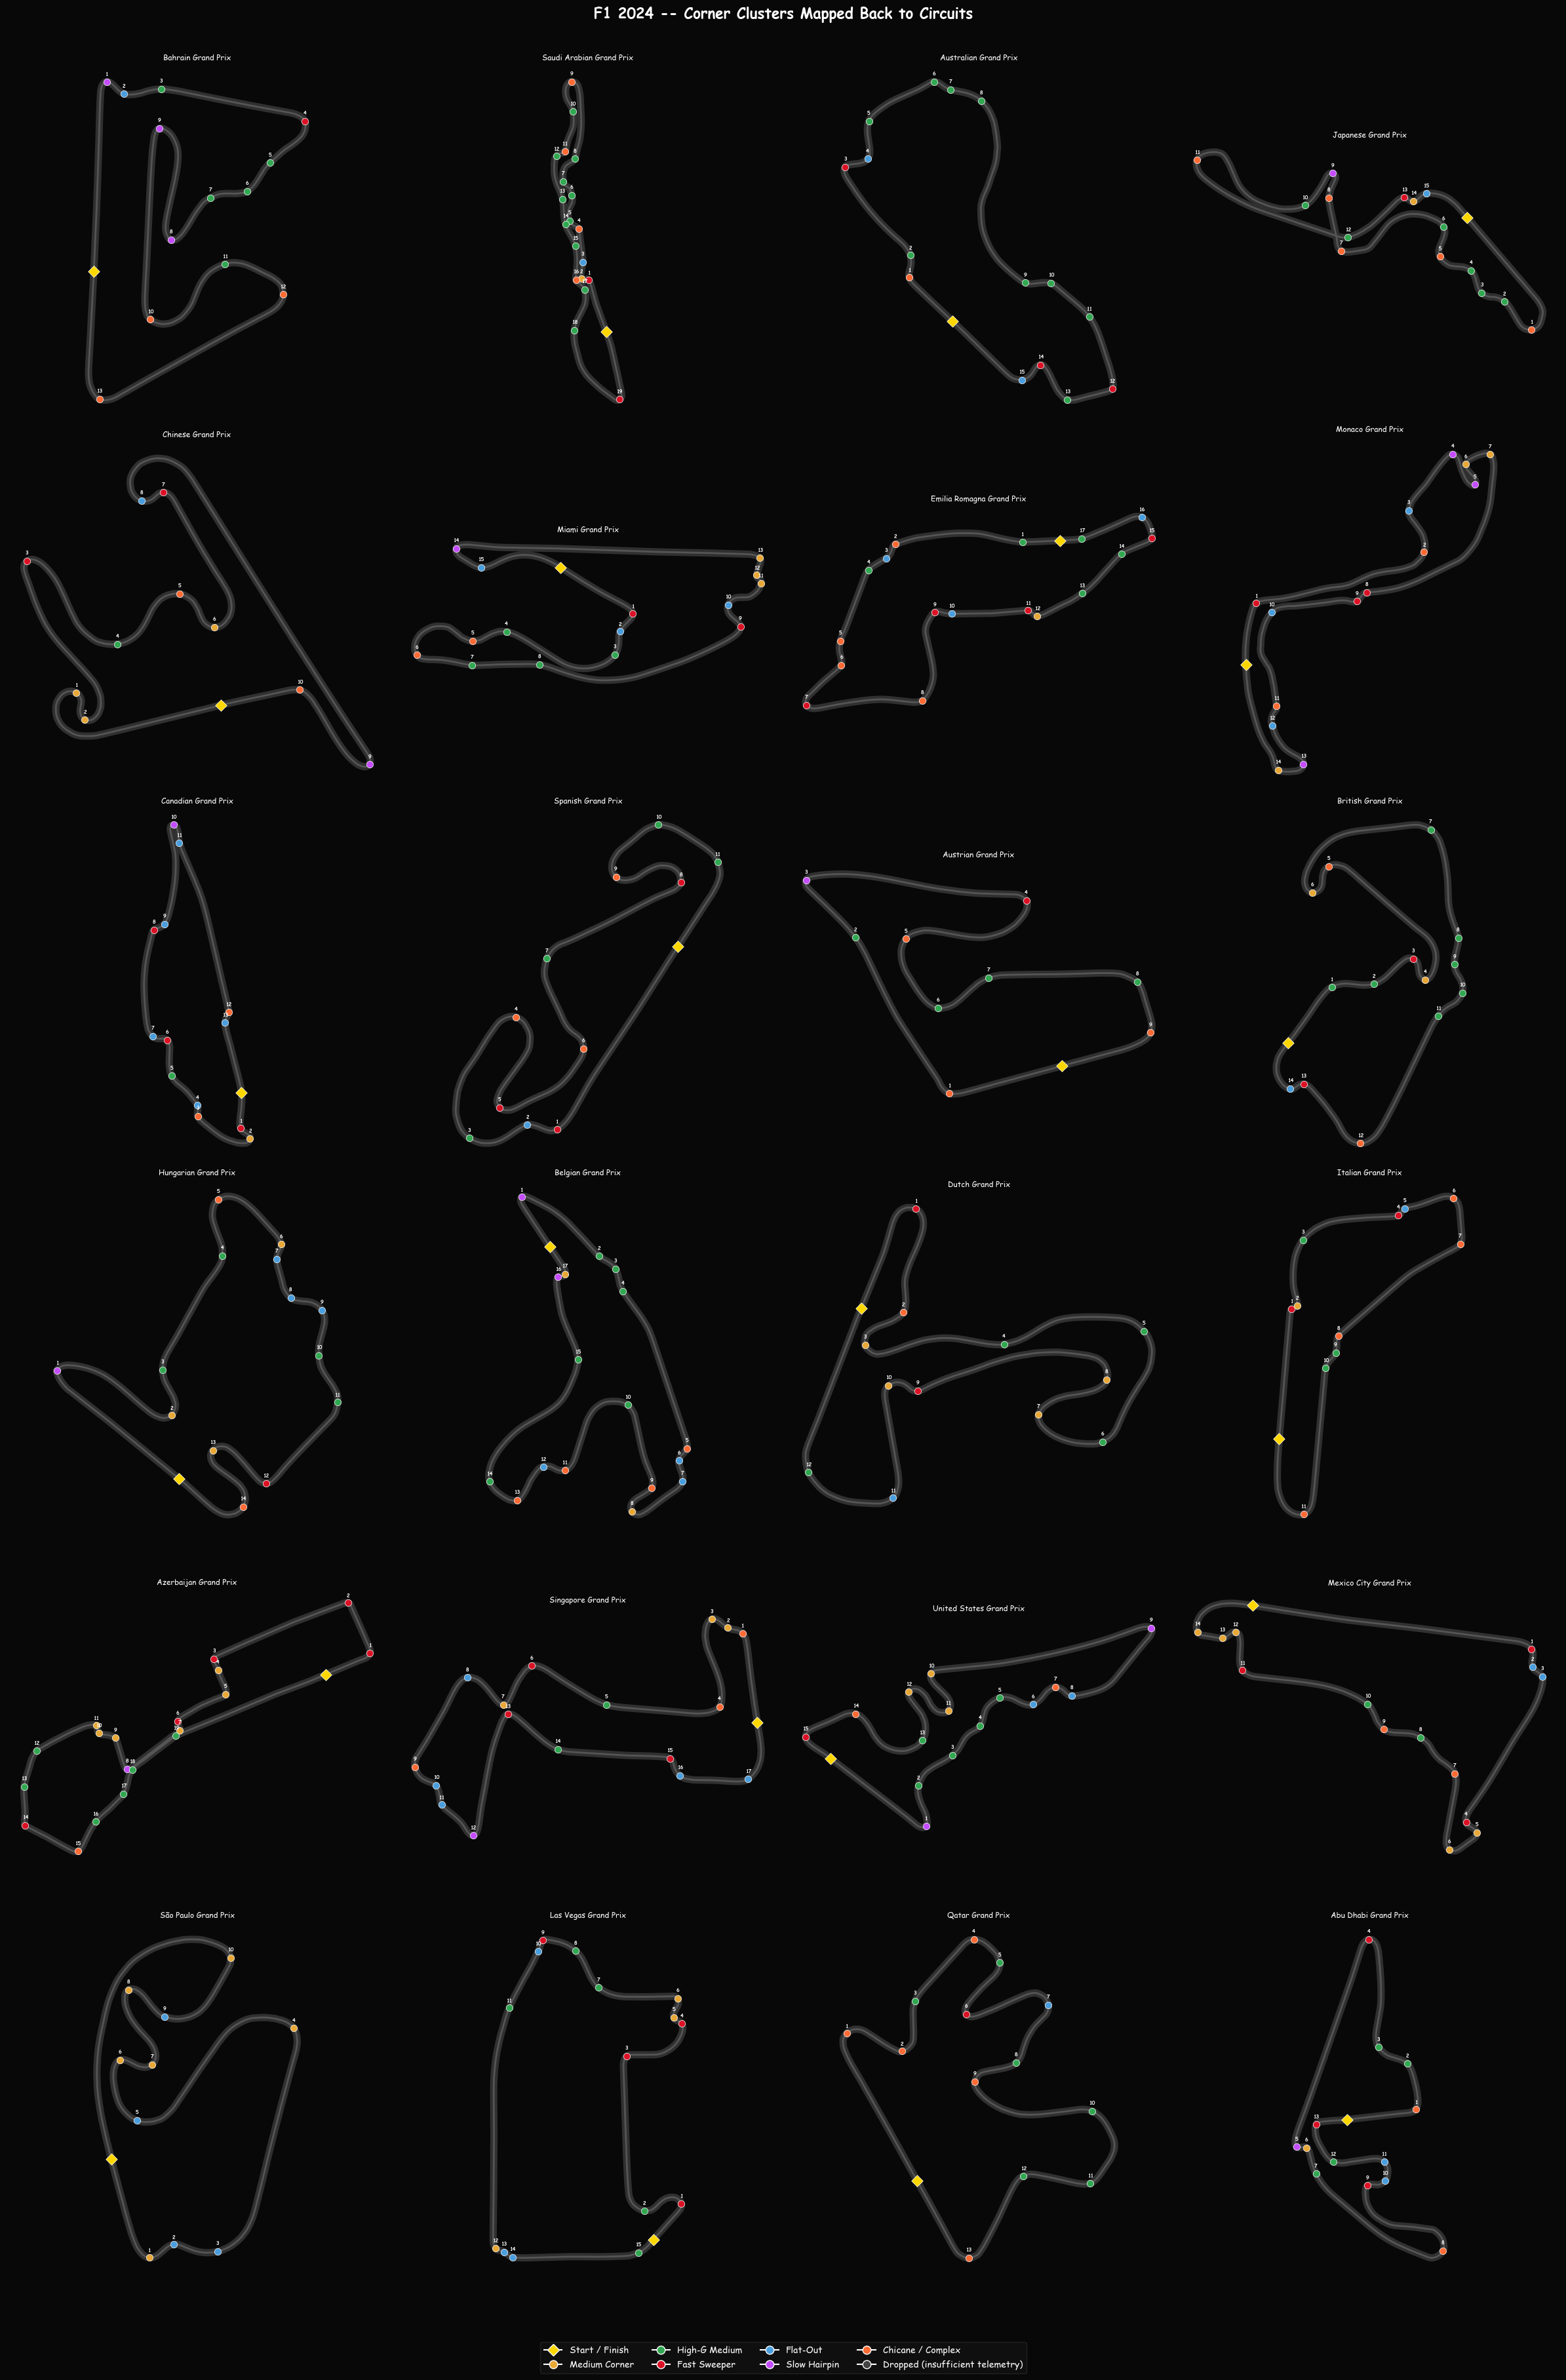

Saved -> Maps/grid_maps/circuit_cluster_maps.png


In [10]:
# Reload GPS + corner positions from cache (fast -- already downloaded),
# then plot a map grid coloring each corner apex by its cluster label.

from matplotlib.lines import Line2D

loaded_gps = {}  # gp -> (x_s, y_s, corners list)

for gp in TRACKS:
    if df_clean[df_clean['circuit'] == gp].empty:
        continue
    try:
        session = fastf1.get_session(YEAR, gp, SESSION)
        session.load(telemetry=True, laps=True, weather=False, messages=False)
        fastest = session.laps.pick_fastest()
        if fastest is None or (isinstance(fastest, pd.Series) and fastest.empty):
            fastest = session.laps.sort_values('LapTime').iloc[0]
        tel          = fastest.get_telemetry().add_distance()
        dist         = tel['Distance'].values.astype(float)
        speed        = tel['Speed'].values.astype(float)
        kappa, x_s, y_s = compute_curvature(
            tel['X'].values.astype(float),
            tel['Y'].values.astype(float),
        )
        kappa_smooth = gaussian_filter1d(kappa, sigma=5)
        abs_kappa    = np.abs(kappa_smooth)
        steer_arr    = tel['Steering'].values.astype(float) if 'Steering' in tel.columns else None
        target       = CORNER_COUNT_OVERRIDES.get(gp) or KNOWN_CORNER_COUNTS.get(gp)
        corners      = detect_corners(
            abs_kappa, dist, speed, kappa_smooth,
            target_count=target,
            steering_arr=steer_arr,
            steer_dist=dist if steer_arr is not None else None,
        )
        loaded_gps[gp] = (x_s, y_s, corners)
    except Exception as exc:
        warnings.warn(f'Skip {gp}: {exc}')

print(f'GPS loaded for {len(loaded_gps)} circuits')

# Build label -> color lookup from the cluster mapping established in Section 4
label_color = {
    cluster_to_label[cid]: CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
    for cid in sorted(cluster_to_label)
}

n_cols = 4
n_rows = int(np.ceil(len(loaded_gps) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 6 * n_rows),
    squeeze=False,
)
fig.patch.set_facecolor('#080808')

for idx, (gp, (x_s, y_s, corners)) in enumerate(loaded_gps.items()):
    ri, ci = divmod(idx, n_cols)
    ax     = axes[ri][ci]
    # Index this circuit's rows by corner number for fast lookup
    gp_df  = df_clean[df_clean['circuit'] == gp].set_index('corner_num')

    ax.set_facecolor('#0d0d0d')
    ax.set_aspect('equal')
    ax.axis('off')

    # Track outline
    ax.plot(x_s, y_s, color='#303030', linewidth=8, solid_capstyle='round', zorder=1)
    ax.plot(x_s, y_s, color='#555',    linewidth=2, solid_capstyle='round', zorder=2)
    # Start/finish diamond
    ax.scatter(x_s[0], y_s[0], s=80, color='#ffd700', zorder=5,
               marker='D', edgecolors='white', linewidths=0.5)

    for c in corners:
        num  = c['corner_num']
        xi   = x_s[c['apex_idx']]
        yi   = y_s[c['apex_idx']]
        # Grey out corners that were dropped by the NaN filter in df_clean
        if num in gp_df.index:
            color = label_color.get(gp_df.loc[num, 'cluster_label'], '#888888')
        else:
            color = '#444444'
        ax.scatter(xi, yi, s=55, color=color,
                   edgecolors='white', linewidths=0.5, zorder=4)
        ax.annotate(
            str(num), (xi, yi), xytext=(0, 7),
            textcoords='offset points',
            ha='center', fontsize=5.5,
            color='white', fontweight='bold', zorder=6,
        )

    ax.set_title(gp, color='white', fontsize=8.5, pad=6)

# Hide unused subplots
for idx in range(len(loaded_gps), n_rows * n_cols):
    ri, ci = divmod(idx, n_cols)
    axes[ri][ci].set_visible(False)

# Legend: start/finish + one entry per cluster label
legend_handles = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#ffd700',
           markersize=9, label='Start / Finish'),
]
for label, color in label_color.items():
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
               markersize=9, label=label)
    )
legend_handles.append(
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#444',
           markersize=9, label='Dropped (insufficient telemetry)')
)

fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    fontsize=10, framealpha=0.4, bbox_to_anchor=(0.5, 0.0),
)
fig.suptitle(
    f'F1 {YEAR} -- Corner Clusters Mapped Back to Circuits',
    fontsize=16, color='white', y=1.005, fontweight='bold',
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('Maps/grid_maps/circuit_cluster_maps.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved -> Maps/grid_maps/circuit_cluster_maps.png')